# Chapter 2 — Framework 1: Chemical stressor score construction and corridor bifurcation

This notebook constructs site-level chemical stressor scores from the chemical matrix and visualizes the resulting low-score and high-score site bifurcation.

The execution structure is:

```text
Inputs → Definition Corner → Process → Outputs and Visualization
```

The workflow loads the site metadata and chemical matrix, defines the reusable PCA, rotation, scoring, and plotting helpers in a dedicated Definition Corner, prepares all result objects in the Process section, and then displays and saves the final tables and figures in one compact output cell.

# Inputs

Load the site metadata and chemical matrix used for Framework 1.

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd

STUDY_CASE = "corridor"  # Set to "DR" to use the hard-saved Detroit River case inputs.
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
MAPS_DIR = METADATA_DIR / "maps"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
FIGURE_DIR = CASE_ROOT_DIR / "figures"
RESULTS_DIR = CASE_ROOT_DIR / "results"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INFO_PATH = METADATA_DIR / "Info.xlsx"
CHEMICAL_PATH = METADATA_DIR / "M.xlsx"

site_info = pd.read_excel(INFO_PATH).reset_index(drop=True)

print(f"{STUDY_CASE_LABEL}: using {site_info.shape[0]} sites")
print(f"Input site metadata: {INFO_PATH}")
print(f"Input chemical matrix: {CHEMICAL_PATH}")
print(f"Input map directory: {MAPS_DIR}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Corridor case study: using 310 sites
Input site metadata: ../data/Info.xlsx
Input chemical matrix: ../data/M.xlsx
Input map directory: ../data/maps
Artifact directory: ../artifacts
Figure directory: ../figures
Results directory: ../results


In [30]:
site_ids = site_info[SITE_ID_COLUMN].rename(SITE_ID_COLUMN)

chemical_raw = pd.read_excel(CHEMICAL_PATH).reset_index(drop=True)
if len(chemical_raw) != len(site_info):
    raise ValueError(
        f"Chemical matrix row count ({len(chemical_raw)}) does not match site metadata row count ({len(site_info)})."
    )

chemical_with_site_id = pd.concat([site_ids.reset_index(drop=True), chemical_raw], axis=1)
chemical_matrix = chemical_with_site_id.set_index(SITE_ID_COLUMN)
chemical_columns = chemical_matrix.columns.tolist()

print(f"Loaded chemical matrix for {STUDY_CASE_LABEL}: {chemical_matrix.shape[0]} sites x {chemical_matrix.shape[1]} chemicals")
display(chemical_with_site_id.head())

Loaded chemical matrix for Corridor case study: 310 sites x 16 chemicals


,Integrated Code,Co,Al,Ni,Mn,Fe,Cr,Cu,Hg,Pb,Zn,SumPCBs,Cd,OCS,"p,p'-DDE",As,Ca
0,DR-02,3.653624,4.742525,4.307142,257.010460,11.249593,12.128824,11.123978,0.983427,22.630486,18.370618,3.973114,1.270737,0.020000,0.570591,23.452117,54.338515
1,DR-03,3.164832,3.509922,3.394234,33.163576,8.870216,9.578770,8.718024,0.648958,0.000400,57.245478,0.814339,0.224713,0.010000,0.182532,0.832938,48.502334
2,DR-04,2.984709,3.670730,2.253268,112.384890,6.549446,9.044796,4.487565,0.580952,13.744258,23.481343,2.205706,0.673739,0.024000,0.391947,12.978875,16.074532
3,DR-06,10.625940,20.375806,17.585138,370.886050,24.168148,32.899916,31.173849,4.598879,47.078350,309.312825,6.013083,3.066512,0.872571,1.147528,45.729737,53.759041
4,DR-07,3.549781,3.827601,2.097337,89.789433,9.337299,9.366623,12.489613,0.699597,19.450930,33.672548,0.730278,1.103482,0.216029,0.168522,23.179911,30.206203


# Definition Corner

The following cell defines the reusable helpers used by the visible workflow below. It can be collapsed during reading so the notebook narrative stays focused on the Framework 1 computation and final outputs.

In [31]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Tuple

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import geopandas as gpd
except ImportError:
    gpd = None


def validate_chemical_matrix(matrix: pd.DataFrame, expected_n_chemicals: int = 16) -> None:
    """Validate the chemical matrix before transformation and PCA."""
    if matrix.shape[1] != expected_n_chemicals:
        raise ValueError(
            f"Expected {expected_n_chemicals} chemical variables for correlation-based PCA, "
            f"found {matrix.shape[1]}."
        )
    if matrix.isna().any().any():
        missing = int(matrix.isna().sum().sum())
        raise ValueError(f"Chemical matrix contains {missing} missing values. Handle them before PCA.")
    if (matrix < 0).any().any():
        raise ValueError("log10(x + 1) transformation requires nonnegative chemical values.")


def log10_plus_one_transformer(matrix: pd.DataFrame) -> pd.DataFrame:
    """Compress raw chemical magnitudes with log10(x + 1)."""
    return np.log10(matrix + 1.0)


def zscore_standardizer(matrix: pd.DataFrame) -> pd.DataFrame:
    """Column-standardize a matrix to mean 0 and sample standard deviation 1."""
    return (matrix - matrix.mean()) / matrix.std(ddof=1)


def correlation_matrix_constructor(transformed_matrix: pd.DataFrame) -> pd.DataFrame:
    """Construct the variable-by-variable correlation matrix."""
    return transformed_matrix.corr()


def principal_component_analysis(
    correlation_matrix: pd.DataFrame,
    min_eigenvalue: float = 1.0,
) -> pd.DataFrame:
    """Return raw PCA loadings retained by the Kaiser eigenvalue > 1 rule."""
    eigvals, eigvecs = np.linalg.eigh(correlation_matrix.to_numpy())
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    n_retained_components = int((eigvals > min_eigenvalue).sum())
    if n_retained_components == 0:
        n_retained_components = min(correlation_matrix.shape)

    eigvals_retained = eigvals[:n_retained_components]
    eigvecs_retained = eigvecs[:, :n_retained_components]
    component_names = [f"PC{i + 1}" for i in range(n_retained_components)]

    return pd.DataFrame(
        eigvecs_retained * np.sqrt(eigvals_retained),
        index=correlation_matrix.index,
        columns=component_names,
    )


def orthomax_loading_rotator(
    raw_loadings: pd.DataFrame,
    gamma: float,
    q: int = 100,
    tol: float = 1e-6,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Rotate loading vectors with the orthomax family and return the rotation matrix."""
    loadings_array = raw_loadings.to_numpy(dtype=float)
    n_variables, n_components = loadings_array.shape

    if n_components < 2:
        return raw_loadings.copy(), np.eye(n_components)

    rotation_matrix = np.eye(n_components)
    criterion_value = 0.0

    for _ in range(q):
        rotated = loadings_array @ rotation_matrix
        basis = loadings_array.T @ (
            rotated ** 3 - (gamma / n_variables) * rotated @ np.diag((rotated ** 2).sum(axis=0))
        )
        u, singular_values, vh = np.linalg.svd(basis)
        rotation_matrix = u @ vh
        updated_criterion = singular_values.sum()
        if updated_criterion < criterion_value * (1 + tol):
            break
        criterion_value = updated_criterion

    rotated_loadings = loadings_array @ rotation_matrix

    # Keep component signs stable so downstream scores remain interpretable run-to-run.
    for column_index in range(rotated_loadings.shape[1]):
        if rotated_loadings[:, column_index].sum() < 0:
            rotated_loadings[:, column_index] *= -1.0
            rotation_matrix[:, column_index] *= -1.0

    rotated_frame = pd.DataFrame(
        rotated_loadings,
        index=raw_loadings.index,
        columns=raw_loadings.columns,
    )
    return rotated_frame, rotation_matrix


def quartimax_loading_rotator(raw_loadings: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    """Rotate PCA loadings using quartimax rotation."""
    return orthomax_loading_rotator(raw_loadings, gamma=0.0)


def stressor_projector(
    transformed_matrix: pd.DataFrame,
    rotated_loadings: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Project standardized transformed chemistry into rotated stressor coordinates."""
    standardized_matrix = zscore_standardizer(transformed_matrix)
    site_scores = standardized_matrix @ rotated_loadings
    site_scores.index.name = "Integrated Code"
    return standardized_matrix, site_scores


def sum_value_selector(vector: pd.Series) -> float:
    """Additive composite score across retained PC stressor values."""
    return float(vector.sum())


def max_value_selector(vector: pd.Series) -> float:
    """Worst-component composite score across retained PC stressor values."""
    return float(vector.max())


def loading_table_generator(rotated_loadings: pd.DataFrame) -> pd.DataFrame:
    """Append explained-variation summaries to the rotated loading table."""
    rotated_component_variation = rotated_loadings.pow(2).sum(axis=0)
    rotated_component_proportion = rotated_component_variation / rotated_loadings.shape[0]
    rotated_component_cumulative = rotated_component_proportion.cumsum()

    table = rotated_loadings.round(5).copy()
    table.index.name = "Chemical / Summary"
    table.loc["Explained Variation"] = rotated_component_variation.round(5)
    table.loc["Proportion of Variation"] = rotated_component_proportion.round(5)
    table.loc["Cumulative Variation"] = rotated_component_cumulative.round(5)
    return table


_WATERBODY_STYLE: Dict[str, Dict] = {
    "DR": {"marker": "^", "label": "Detroit River"},
    "SCR": {"marker": "o", "label": "St. Clair River"},
    "LSC": {"marker": "s", "label": "Lake St. Clair"},
}

_BIFURCATION_COLORS = {
    "above": "#d62728",
    "middle": "#cccccc19",
    "below": "#2ca02c",
}


def resolve_n_ref(threshold_quantile: int | float, n_total: int) -> int:
    """Resolve either a count or a proportion into a lower/upper tail count."""
    if n_total <= 0:
        raise ValueError("n_total must be positive.")
    if threshold_quantile > 1:
        n_ref = int(threshold_quantile)
    else:
        n_ref = int(round(float(threshold_quantile) * n_total))
    return max(1, min(n_ref, n_total // 2))


def _is_detroit_river_case(study_case: str | None = None) -> bool:
    selected_case = study_case if study_case is not None else globals().get("STUDY_CASE", "")
    return str(selected_case).upper() == "DR"


def _set_map_extent_from_points(ax: plt.Axes, lon: pd.Series | None, lat: pd.Series | None) -> bool:
    if lon is None or lat is None:
        return False

    lon_values = pd.Series(lon).dropna().astype(float)
    lat_values = pd.Series(lat).dropna().astype(float)
    if lon_values.empty or lat_values.empty:
        return False

    lon_min, lon_max = float(lon_values.min()), float(lon_values.max())
    lat_min, lat_max = float(lat_values.min()), float(lat_values.max())
    lon_padding = max((lon_max - lon_min) * 0.12, 0.03)
    lat_padding = max((lat_max - lat_min) * 0.12, 0.03)

    ax.set_xlim(lon_min - lon_padding, lon_max + lon_padding)
    ax.set_ylim(lat_min - lat_padding, lat_max + lat_padding)
    return True


def plot_corridor_map(
    ax: plt.Axes,
    maps_dir: str | Path,
    *,
    study_case: str | None = None,
    lat: pd.Series | None = None,
    lon: pd.Series | None = None,
    annotate: bool = True,
    annotation_fontsize: int = 10,
) -> plt.Axes:
    """Draw either the full SCDRS corridor background or the Detroit River-only background."""
    maps_dir = Path(maps_dir)
    is_dr_case = _is_detroit_river_case(study_case)

    shapefiles = {
        "lake_stclair": maps_dir / "lake_stclair" / "lake_stclair.shp",
        "lake_erie": maps_dir / "lake_erie" / "lake_erie.shp",
        "lake_huron": maps_dir / "lake_huron" / "lake_huron.shp",
        "detroit_river": maps_dir / "detroit_river_aoc_shapefile" / "AOC_MI_Detroit_2021.shp",
        "stclair_river": maps_dir / "aoc_mi_stclair_2021" / "AOC_MI_StClair_2021.shp",
    }
    active_shapefiles = [shapefiles["detroit_river"]] if is_dr_case else list(shapefiles.values())

    if gpd is not None:
        for path in active_shapefiles:
            if path.exists():
                gdf = gpd.read_file(path).to_crs(epsg=4326)
                gdf.plot(ax=ax, color="lightblue", edgecolor="none", alpha=0.5)

    if is_dr_case:
        if not _set_map_extent_from_points(ax, lon=lon, lat=lat):
            ax.set_ylim(42.0, 42.4)
            ax.set_xlim(-83.28, -82.95)
            
        ax.set_xticks([-83.25, -83.15, -83.05, -82.95])
    else:
        ax.set_ylim(42.0, 43.1)
        ax.set_xlim(-83.3, -82.3)

    if annotate:
        kw = dict(color="gray", style="italic")
        if is_dr_case:
            x_left, x_right = ax.get_xlim()
            y_bottom, y_top = ax.get_ylim()
            ax.text(
                -83.05,
                42.18,
                "Detroit River",
                fontsize=20,
                **kw,
            )
        else:
            ax.text(-83.00, 42.20, "Detroit River", **kw)
            ax.text(-82.85, 42.90, "St. Clair River", **kw)
            ax.text(-82.55, 42.05, "Lake Erie", **kw)
            ax.text(-83.00, 42.50, "Lake St. Clair", **kw)
            ax.text(-82.60, 43.05, "Lake Huron", **kw)

    return ax


def plot_corridor_bifurcation(
    scores: pd.Series,
    lat: pd.Series,
    lon: pd.Series,
    waterbody: pd.Series,
    maps_dir: str | Path,
    *,
    study_case: str | None = None,
    threshold_quantile: int | float = 0.20,
    score_label: str = "Pollution Score",
    waterbody_styles: Dict[str, Dict] | None = None,
    above_color: str | None = None,
    middle_color: str | None = None,
    below_color: str | None = None,
    figsize: Tuple[int, int] = (16, 7),
    label_fontsize: int = 14,
) -> Tuple[plt.Figure, np.ndarray]:
    """Plot map-based and ECDF-based score bifurcation for one score vector."""
    wb_styles = waterbody_styles or _WATERBODY_STYLE
    c_below = below_color or _BIFURCATION_COLORS["below"]
    c_middle = middle_color or _BIFURCATION_COLORS["middle"]
    c_above = above_color or _BIFURCATION_COLORS["above"]
    active_study_case = study_case if study_case is not None else globals().get("STUDY_CASE", None)

    aligned = pd.concat(
        {
            "score": scores,
            "lat": lat,
            "lon": lon,
            "waterbody": waterbody,
        },
        axis=1,
        join="inner",
    ).dropna(subset=["score", "lat", "lon", "waterbody"] )

    if aligned.empty:
        raise ValueError("No aligned sites are available for corridor bifurcation plotting.")

    scores = aligned["score"]
    lat = aligned["lat"]
    lon = aligned["lon"]
    waterbody = aligned["waterbody"]

    n_total = len(scores)
    n_lo = resolve_n_ref(threshold_quantile, n_total)
    n_hi = n_lo

    lower_val = scores.nsmallest(n_lo).max()
    upper_val = scores.nlargest(n_hi).min()

    is_below = scores <= lower_val
    is_above = scores >= upper_val
    is_middle = ~is_below & ~is_above

    n_below = int(is_below.sum())
    n_middle = int(is_middle.sum())
    n_above = int(is_above.sum())

    lbl_below = f"Lowest {n_below} sites"
    lbl_above = f"Highest {n_above} sites"

    fig = plt.figure(figsize=figsize, dpi=300, constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.02)
    ax_map = fig.add_subplot(gs[0])
    ax_ecdf = fig.add_subplot(gs[1])

    plot_corridor_map(
        ax_map,
        maps_dir,
        study_case=active_study_case,
        lat=lat,
        lon=lon,
        annotate=True,
        annotation_fontsize=label_fontsize - 2,
    )

    site_color = pd.Series(c_middle, index=scores.index)
    site_color[is_below] = c_below
    site_color[is_above] = c_above

    for wb_key, style in wb_styles.items():
        mask = waterbody == wb_key
        if mask.sum() == 0:
            continue
        ax_map.scatter(
            lon[mask],
            lat[mask],
            c=site_color[mask],
            s=85,
            alpha=0.8,
            edgecolors="white",
            linewidths=0.4,
            zorder=3,
        )

    colour_handles = [
        mlines.Line2D([], [], color=c_below, marker="o", linestyle="None", markersize=9, label=lbl_below),
        mlines.Line2D([], [], color=c_middle, marker="o", linestyle="None", markersize=9, label=f"Middle (n={n_middle})"),
        mlines.Line2D([], [], color=c_above, marker="o", linestyle="None", markersize=9, label=lbl_above),
    ]
    ax_map.legend(handles=colour_handles, loc="upper left", fontsize=label_fontsize - 1, framealpha=0.9, ncol=1)
    ax_map.set_xlabel("Longitude", fontsize=label_fontsize)
    ax_map.set_ylabel("Latitude", fontsize=label_fontsize)
    ax_map.tick_params(labelsize=label_fontsize - 1)
    ax_map.grid(linestyle="--", alpha=0.4)

    sorted_scores = np.sort(scores.dropna().values)
    n = len(sorted_scores)
    cum_prob = np.arange(1, n + 1) / n
    lower_q = n_below / n_total
    upper_q = 1.0 - n_above / n_total

    ax_ecdf.step(sorted_scores, cum_prob, where="post", linewidth=2.5, color="darkblue", alpha=0.8, label="ECDF")

    ref_scores = sorted_scores[sorted_scores <= lower_val]
    ax_ecdf.fill_between(ref_scores, 0, lower_q, alpha=0.25, color=c_below, label=lbl_below, zorder=1)
    ax_ecdf.plot([lower_val, lower_val], [0, lower_q], color=c_below, ls="--", lw=1.5, alpha=0.7, zorder=3)
    ax_ecdf.plot([sorted_scores[0] - 0.3, lower_val], [lower_q, lower_q], color=c_below, ls="--", lw=1.5, alpha=0.7, zorder=3)

    top_scores = sorted_scores[sorted_scores >= upper_val]
    ax_ecdf.fill_between(top_scores, upper_q, 1.0, alpha=0.20, color=c_above, label=lbl_above, zorder=1)
    ax_ecdf.plot([upper_val, upper_val], [upper_q, 1.0], color=c_above, ls="--", lw=1.5, alpha=0.7, zorder=3)
    ax_ecdf.plot([upper_val, sorted_scores[-1] + 0.8], [upper_q, upper_q], color=c_above, ls="--", lw=1.5, alpha=0.7, zorder=3)

    for pct in (10, 25, 50, 75, 90):
        ax_ecdf.axhline(y=pct / 100, color="gray", ls=":", alpha=0.4, lw=1)
        ax_ecdf.text(sorted_scores[-1] * 1.02, pct / 100, f"{pct}%", fontsize=label_fontsize - 2, color="gray", va="center")

    ax_ecdf.set_xlabel(score_label, fontsize=label_fontsize)
    ax_ecdf.set_ylabel("Cumulative Probability", fontsize=label_fontsize)
    ax_ecdf.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax_ecdf.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"] )
    ax_ecdf.tick_params(labelsize=label_fontsize - 1)
    ax_ecdf.set_ylim(0, 1.05)
    ax_ecdf.set_xlim(sorted_scores[0] - 0.3, sorted_scores[-1] + 0.8)
    ax_ecdf.grid(True, alpha=0.3)
    ax_ecdf.legend(fontsize=label_fontsize - 2, loc="upper left")

    return fig, np.array([ax_map, ax_ecdf])

# Process

The following process cell runs the narrative workflow in order: it validates and transforms the chemical matrix, obtains and rotates PCA loadings, projects sites into stressor space, constructs composite scores, prepares the loading and score tables, and renders the two corridor bifurcation figures for output.

In [32]:
# 1. Validate and transform the raw chemical matrix.
validate_chemical_matrix(chemical_matrix)
chemical_log10 = log10_plus_one_transformer(chemical_matrix)
chemical_correlation_matrix = correlation_matrix_constructor(chemical_log10)

# 2. Compute raw PCA loadings and rotate them with quartimax rotation.
raw_pc_loadings = principal_component_analysis(
    chemical_correlation_matrix,
    min_eigenvalue=0.5,
)
quartimax_loadings, rotation_matrix = quartimax_loading_rotator(raw_pc_loadings)
quartimax_loadings.index.name = "Chemical"

# 3. Project the chemical_log and standardized chemical matrix into the rotated stressor-coordinate space.
chemical_standardized, site_scores_full = stressor_projector(
    transformed_matrix=chemical_log10,
    rotated_loadings=quartimax_loadings,
)

# 4. Construct the site-level composite stressor scores used downstream.
if STUDY_CASE == "corridor":
    summary_drop_components = ["PC2", "PC6"]
elif STUDY_CASE == "DR":
    summary_drop_components = ["PC6", "PC7"]

site_scores_retained = site_scores_full.drop(
    columns=summary_drop_components,
    errors="ignore",
)
site_scores_table = site_scores_retained.copy()
site_scores_table["SumRel"] = site_scores_retained.apply(sum_value_selector, axis=1)
site_scores_table["MaxRel"] = site_scores_retained.apply(max_value_selector, axis=1)
site_scores_table.index.name = "Integrated Code"

# 5. Prepare the output tables.
rotated_loading_table = loading_table_generator(quartimax_loadings)

# 6. Prepare the visualization frame and figure objects.
plot_frame = site_info.set_index("Integrated Code").join(site_scores_table, how="inner")
required_plot_columns = ["Latitude", "Longitude", "Water body", "SumRel", "MaxRel"]
missing_plot_columns = [col for col in required_plot_columns if col not in plot_frame.columns]
if missing_plot_columns:
    raise KeyError(f"Missing columns required for plotting: {missing_plot_columns}")

plot_frame = plot_frame.dropna(subset=required_plot_columns)

sumrel_corridor_fig, _ = plot_corridor_bifurcation(
    scores=plot_frame["SumRel"],
    lat=plot_frame["Latitude"],
    lon=plot_frame["Longitude"],
    waterbody=plot_frame["Water body"],
    maps_dir=MAPS_DIR,
    threshold_quantile=43,
    score_label="SumRel Chemical Stress Score",
)
maxrel_corridor_fig, _ = plot_corridor_bifurcation(
    scores=plot_frame["MaxRel"],
    lat=plot_frame["Latitude"],
    lon=plot_frame["Longitude"],
    waterbody=plot_frame["Water body"],
    maps_dir=MAPS_DIR,
    score_label="MaxRel Chemical Stress Score",
)
plt.close(sumrel_corridor_fig)
plt.close(maxrel_corridor_fig)

framework1_process_summary_table = pd.DataFrame(
    {
        "Object": [
            "chemical_log10",
            "chemical_correlation_matrix",
            "quartimax_loadings",
            "site_scores_table",
            "plot_frame",
        ],
        "Shape": [
            chemical_log10.shape,
            chemical_correlation_matrix.shape,
            quartimax_loadings.shape,
            site_scores_table.shape,
            plot_frame.shape,
        ],
    }
)

print("Framework 1 process objects are prepared for the Outputs and Visualization section.")

Framework 1 process objects are prepared for the Outputs and Visualization section.


# Outputs and Visualization

This compact output cell displays and saves the final Framework 1 tables and figures produced in the Process section.

Rotated PC loading table with explained variation summary


,PC1,PC2,PC3,PC4,PC5,PC6
Chemical / Summary,,,,,,
Co,0.76354,0.45655,0.00615,0.07246,0.34743,0.06092
Al,0.56757,0.67184,0.00789,0.03446,0.32983,0.18482
Ni,0.88186,-0.04351,-0.06543,0.03855,-0.27557,0.06309
Mn,0.58973,0.41491,0.30513,0.16302,-0.26725,0.38352
Fe,0.79231,0.16983,0.02921,0.02446,0.05188,0.23469
Cr,0.95130,0.12673,0.11785,0.00318,-0.02262,0.02220
Cu,0.89986,0.09926,0.09201,-0.07323,0.01836,0.01166
Hg,0.41372,0.14001,0.02361,0.03590,0.80393,0.04855
Pb,0.39334,0.08371,0.76805,0.03688,-0.38194,-0.00151


Site scores table with SumRel and MaxRel


,PC1,PC3,PC4,PC5,SumRel,MaxRel
Integrated Code,,,,,,
DR-02,-3.86958,2.12801,-0.77542,-0.00870,-2.52568,2.12801
DR-03,-9.87294,-3.38262,-1.71686,0.20605,-14.76636,0.20605
DR-04,-9.05322,0.58010,-1.37772,-0.38563,-10.23646,0.58010
DR-06,8.39352,3.91193,0.64977,3.06875,16.02398,8.39352
DR-07,-6.82347,1.47206,-1.21886,0.18056,-6.38972,1.47206
...,...,...,...,...,...,...
DR-159,-6.64543,-1.60156,-1.27205,-1.40682,-10.92586,-1.27205
LSC-64,-2.10507,-0.84937,2.96716,-0.47779,-0.46507,2.96716
LSC-65,-2.60420,-0.68265,1.42784,-0.61028,-2.46930,1.42784


SumRel corridor bifurcation figure


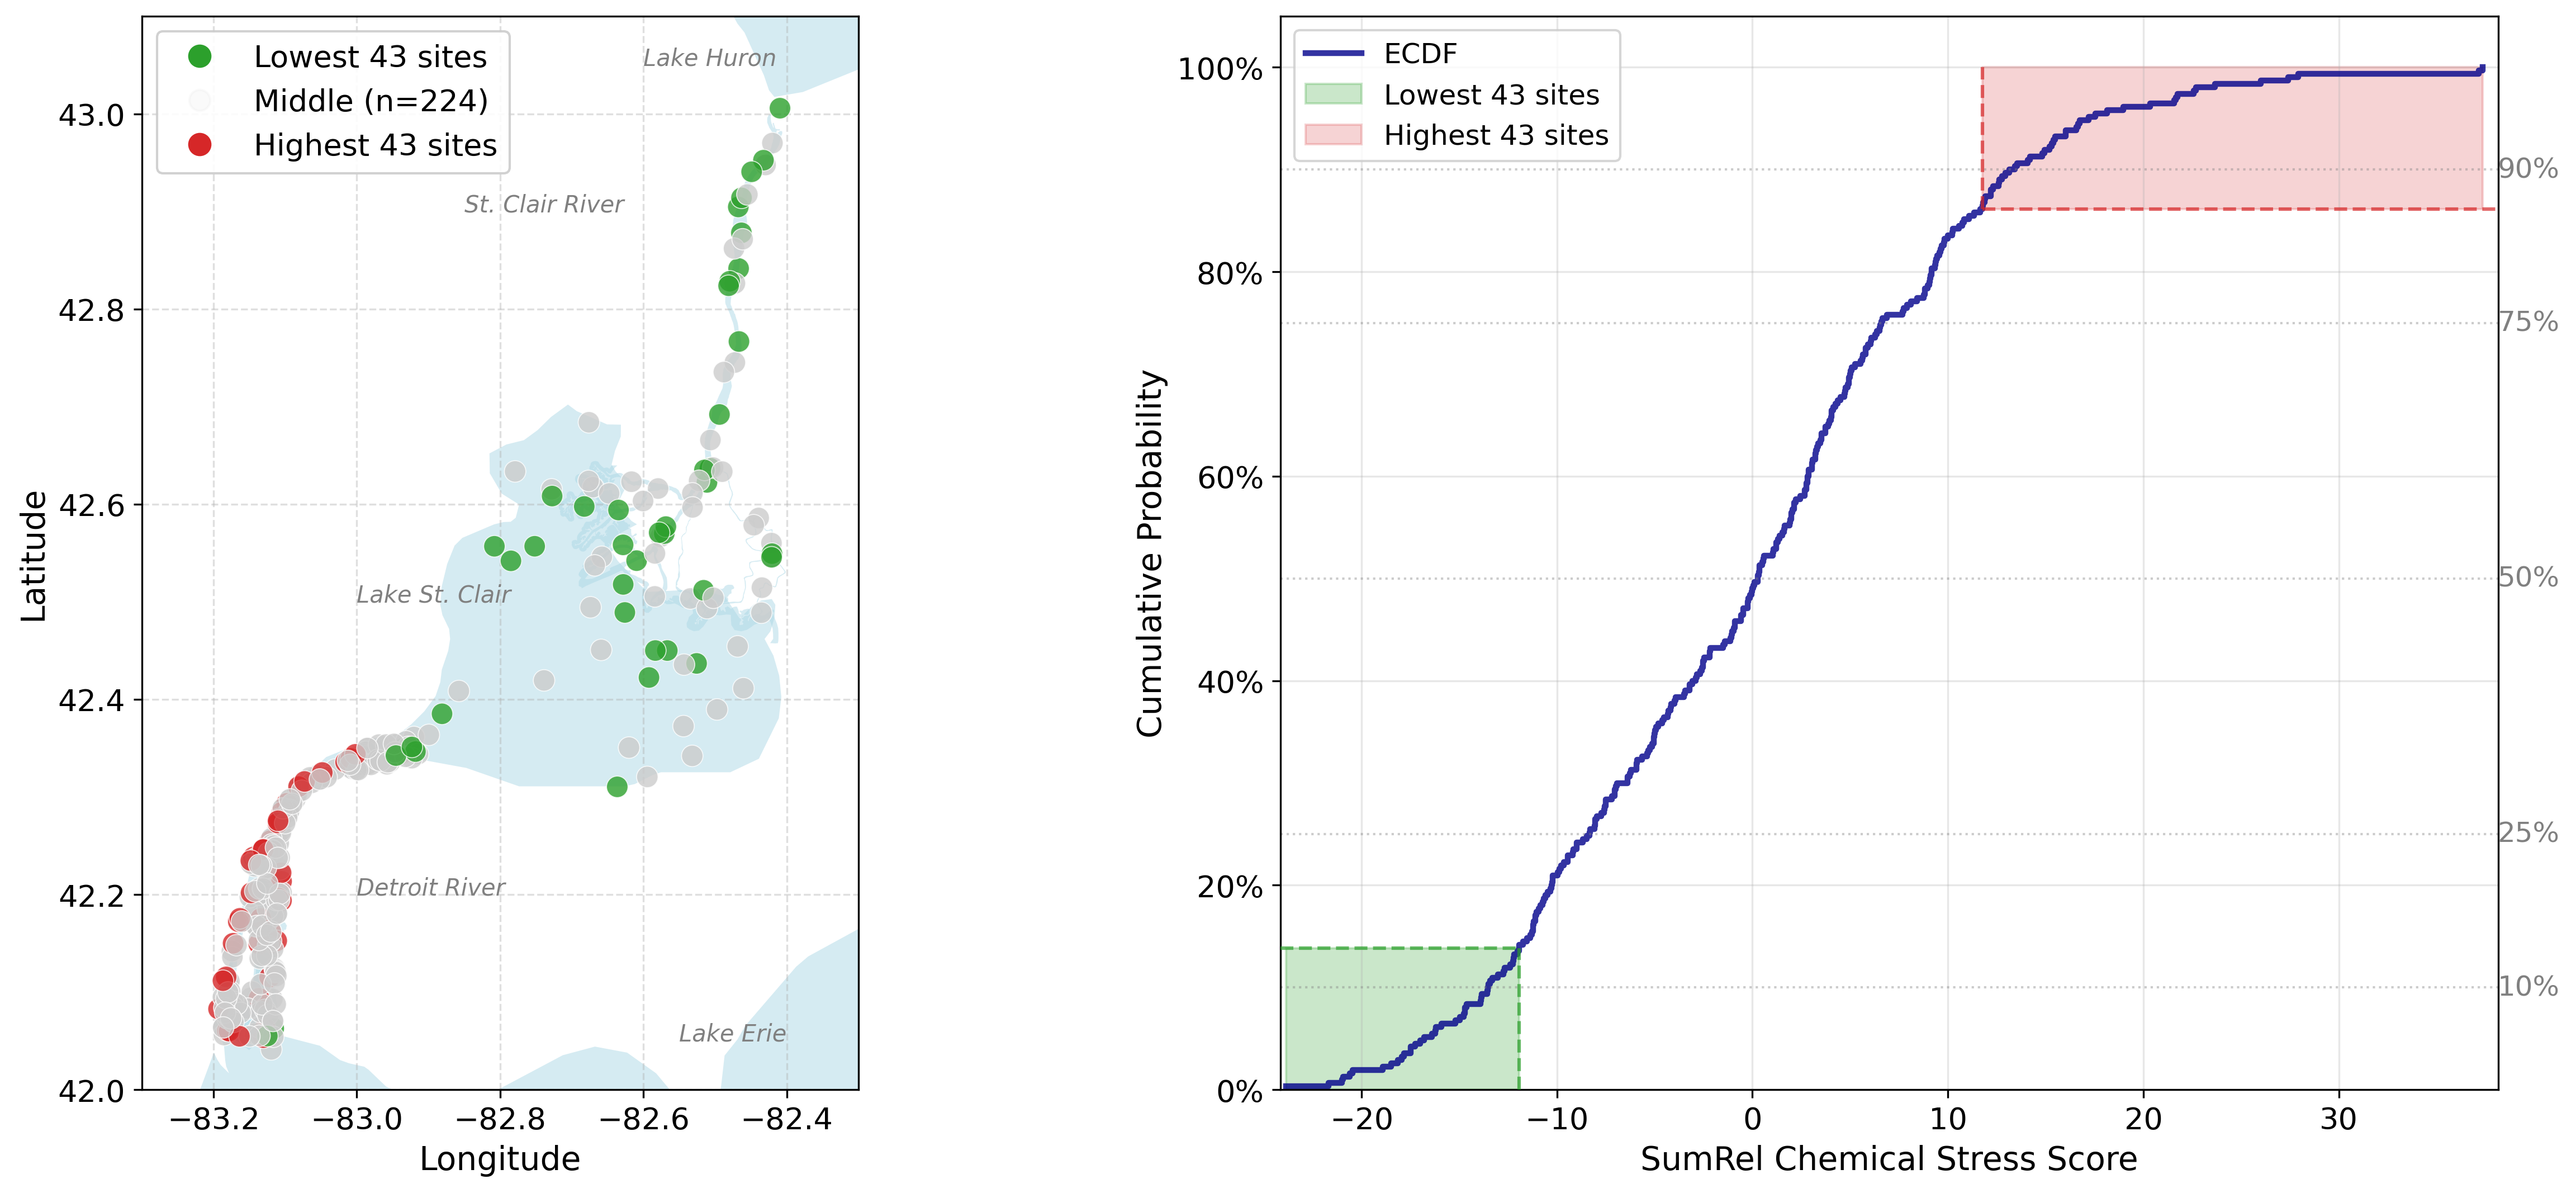

MaxRel corridor bifurcation figure


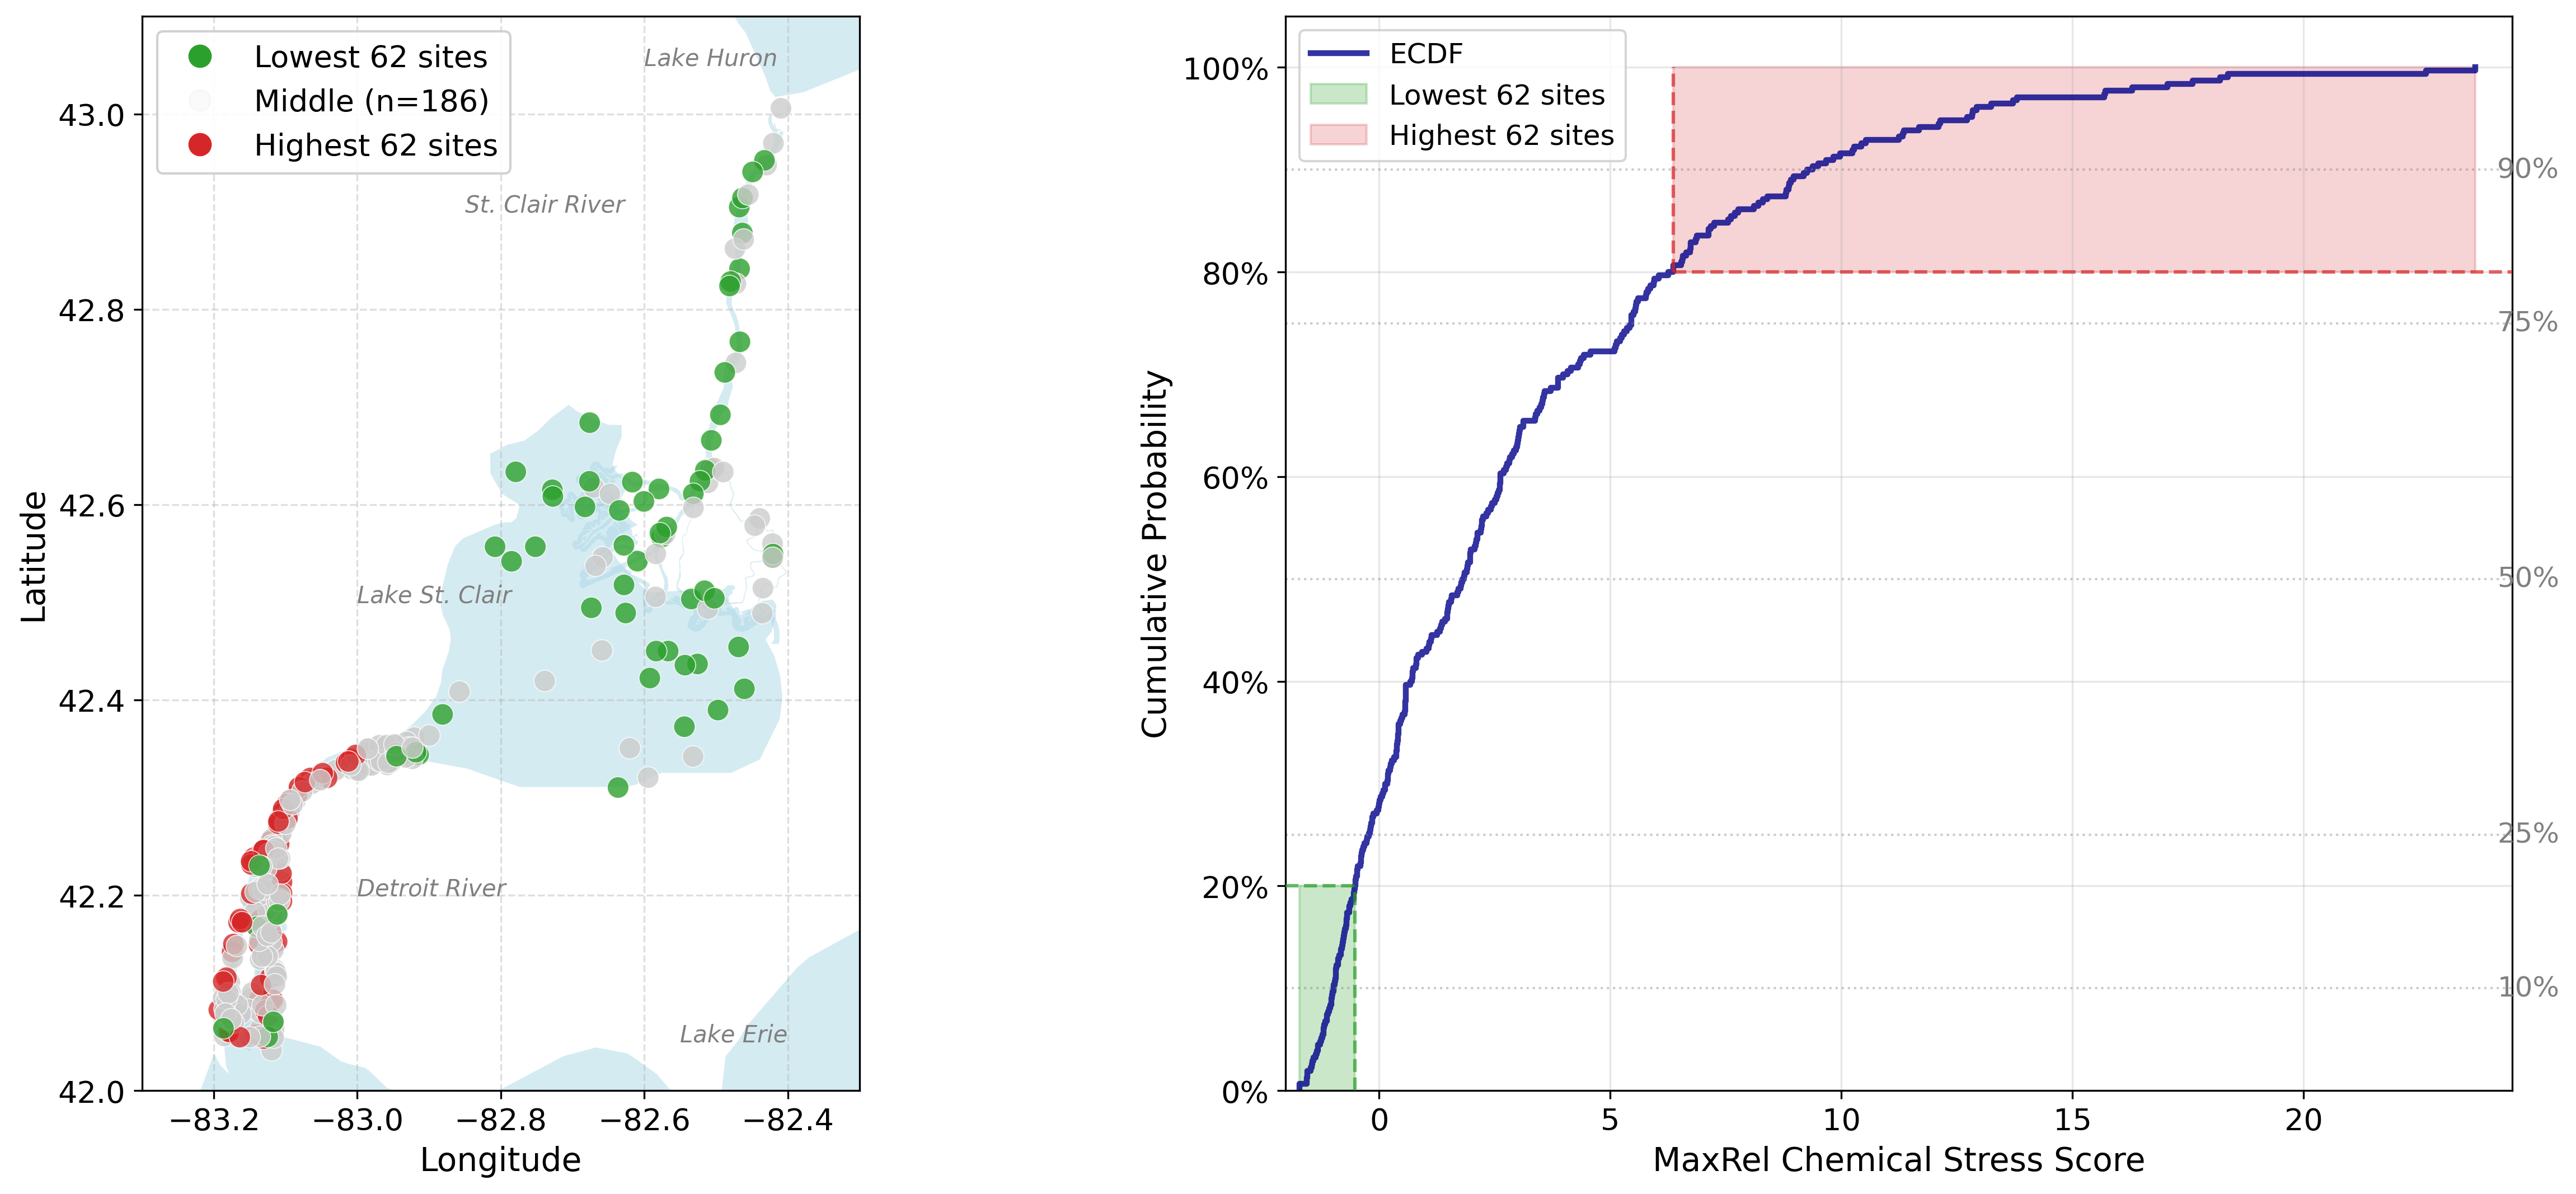

Saved Framework 1 outputs
Result table: ../results/ch2_fw1_rotated_loading_table.xlsx
Artifact table: ../artifacts/A1_stressors_and_scores.xlsx
SumRel figure: ../figures/ch2_fm1_SumRel_corridor_bifurcation.png
MaxRel figure: ../figures/ch2_fm1_MaxRel_corridor_bifurcation.png


In [33]:
rotated_loading_output_table = rotated_loading_table
site_scores_output_table = site_scores_table.round(5)
sumrel_corridor_output_figure = sumrel_corridor_fig
maxrel_corridor_output_figure = maxrel_corridor_fig

loading_result_path = RESULTS_DIR / "ch2_fw1_rotated_loading_table.xlsx"
score_artifact_path = ARTIFACT_DIR / "A1_stressors_and_scores.xlsx"
sumrel_figure_path = FIGURE_DIR / "ch2_fm1_SumRel_corridor_bifurcation.png"
maxrel_figure_path = FIGURE_DIR / "ch2_fm1_MaxRel_corridor_bifurcation.png"

print("Rotated PC loading table with explained variation summary")
display(rotated_loading_output_table)
# save the rotated loading into results folder
rotated_loading_output_table.to_excel(loading_result_path)

print("Site scores table with SumRel and MaxRel")
display(site_scores_output_table)
# save the site contamination scores into artifacts folder
site_scores_table.to_excel(score_artifact_path)

print("SumRel corridor bifurcation figure")
display(sumrel_corridor_output_figure)
# save the SumRel map and ECDF figure into figures folder
sumrel_corridor_output_figure.savefig(sumrel_figure_path, dpi=300, bbox_inches="tight")

print("MaxRel corridor bifurcation figure")
display(maxrel_corridor_output_figure)
# save the MaxRel map and ECDF figure into figures folder
maxrel_corridor_output_figure.savefig(maxrel_figure_path, dpi=300, bbox_inches="tight")

print("Saved Framework 1 outputs")
print(f"Result table: {loading_result_path}")
print(f"Artifact table: {score_artifact_path}")
print(f"SumRel figure: {sumrel_figure_path}")
print(f"MaxRel figure: {maxrel_figure_path}")

# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../results/ch2_fw1_rotated_loading_table.xlsx
../artifacts/A1_stressors_and_scores.xlsx
../figures/ch2_fm1_SumRel_corridor_bifurcation.png
../figures/ch2_fm1_MaxRel_corridor_bifurcation.png
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```

Plain site map using 310 sites


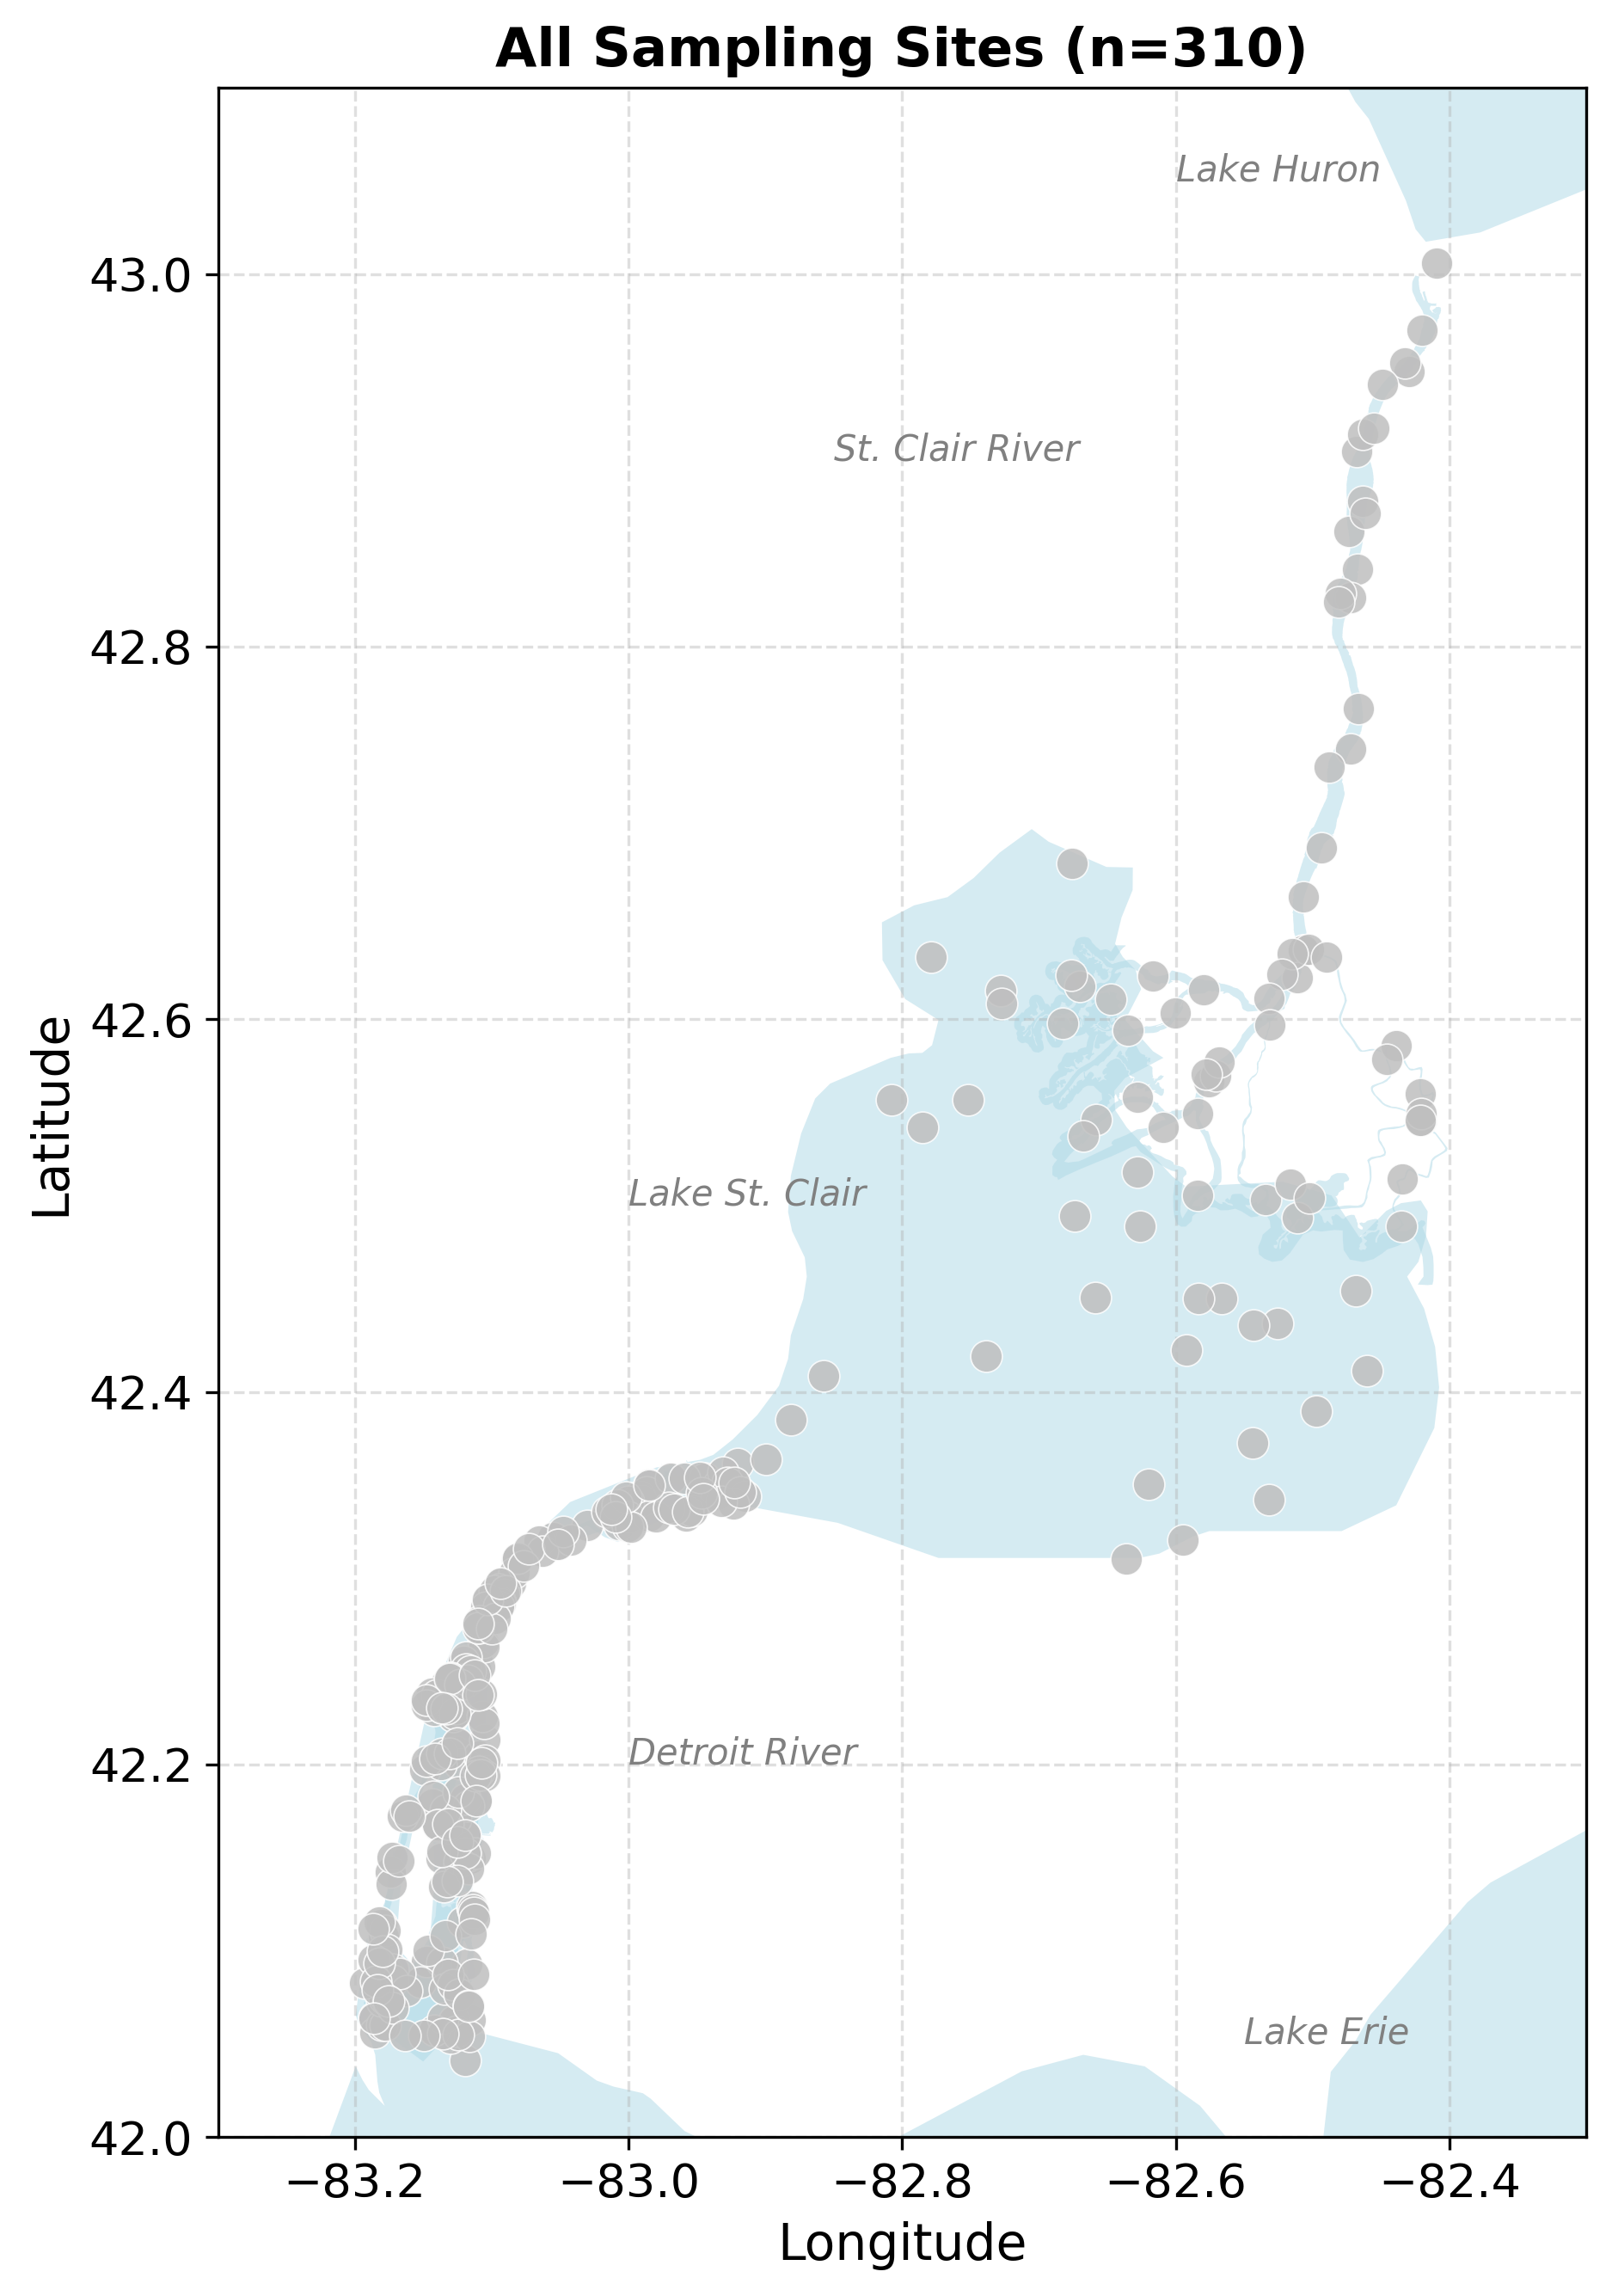

In [34]:
site_location_columns = [SITE_ID_COLUMN, "Latitude", "Longitude"]
missing_site_location_columns = [
    column for column in site_location_columns[1:]
    if column not in site_info.columns
]
if missing_site_location_columns:
    raise KeyError(f"Missing columns required for the plain site map: {missing_site_location_columns}")

all_site_map_frame = site_info[site_location_columns].dropna(subset=["Latitude", "Longitude"]).copy()

all_sites_map_figure, all_sites_map_axis = plt.subplots(figsize=(7.2, 9.0), dpi=300)
plot_corridor_map(
    all_sites_map_axis,
    MAPS_DIR,
    study_case=STUDY_CASE,
    lat=all_site_map_frame["Latitude"],
    lon=all_site_map_frame["Longitude"],
    annotate=True,
)
all_sites_map_axis.scatter(
    all_site_map_frame["Longitude"],
    all_site_map_frame["Latitude"],
    c="#bfbfbf",
    s=78,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.4,
    zorder=3,
)
all_sites_map_axis.set_title(
    f"All Sampling Sites (n={all_site_map_frame.shape[0]})",
    fontsize=15,
    fontweight="bold",
)
all_sites_map_axis.set_xlabel("Longitude", fontsize=14)
all_sites_map_axis.set_ylabel("Latitude", fontsize=14)
all_sites_map_axis.tick_params(labelsize=13)
all_sites_map_axis.grid(linestyle="--", alpha=0.4)
all_sites_map_figure.tight_layout()

print(f"Plain site map using {all_site_map_frame.shape[0]} sites")
display(all_sites_map_figure)
plt.close(all_sites_map_figure)

All-site SumRel count: 310
20th percentile cutoff: -10.24222


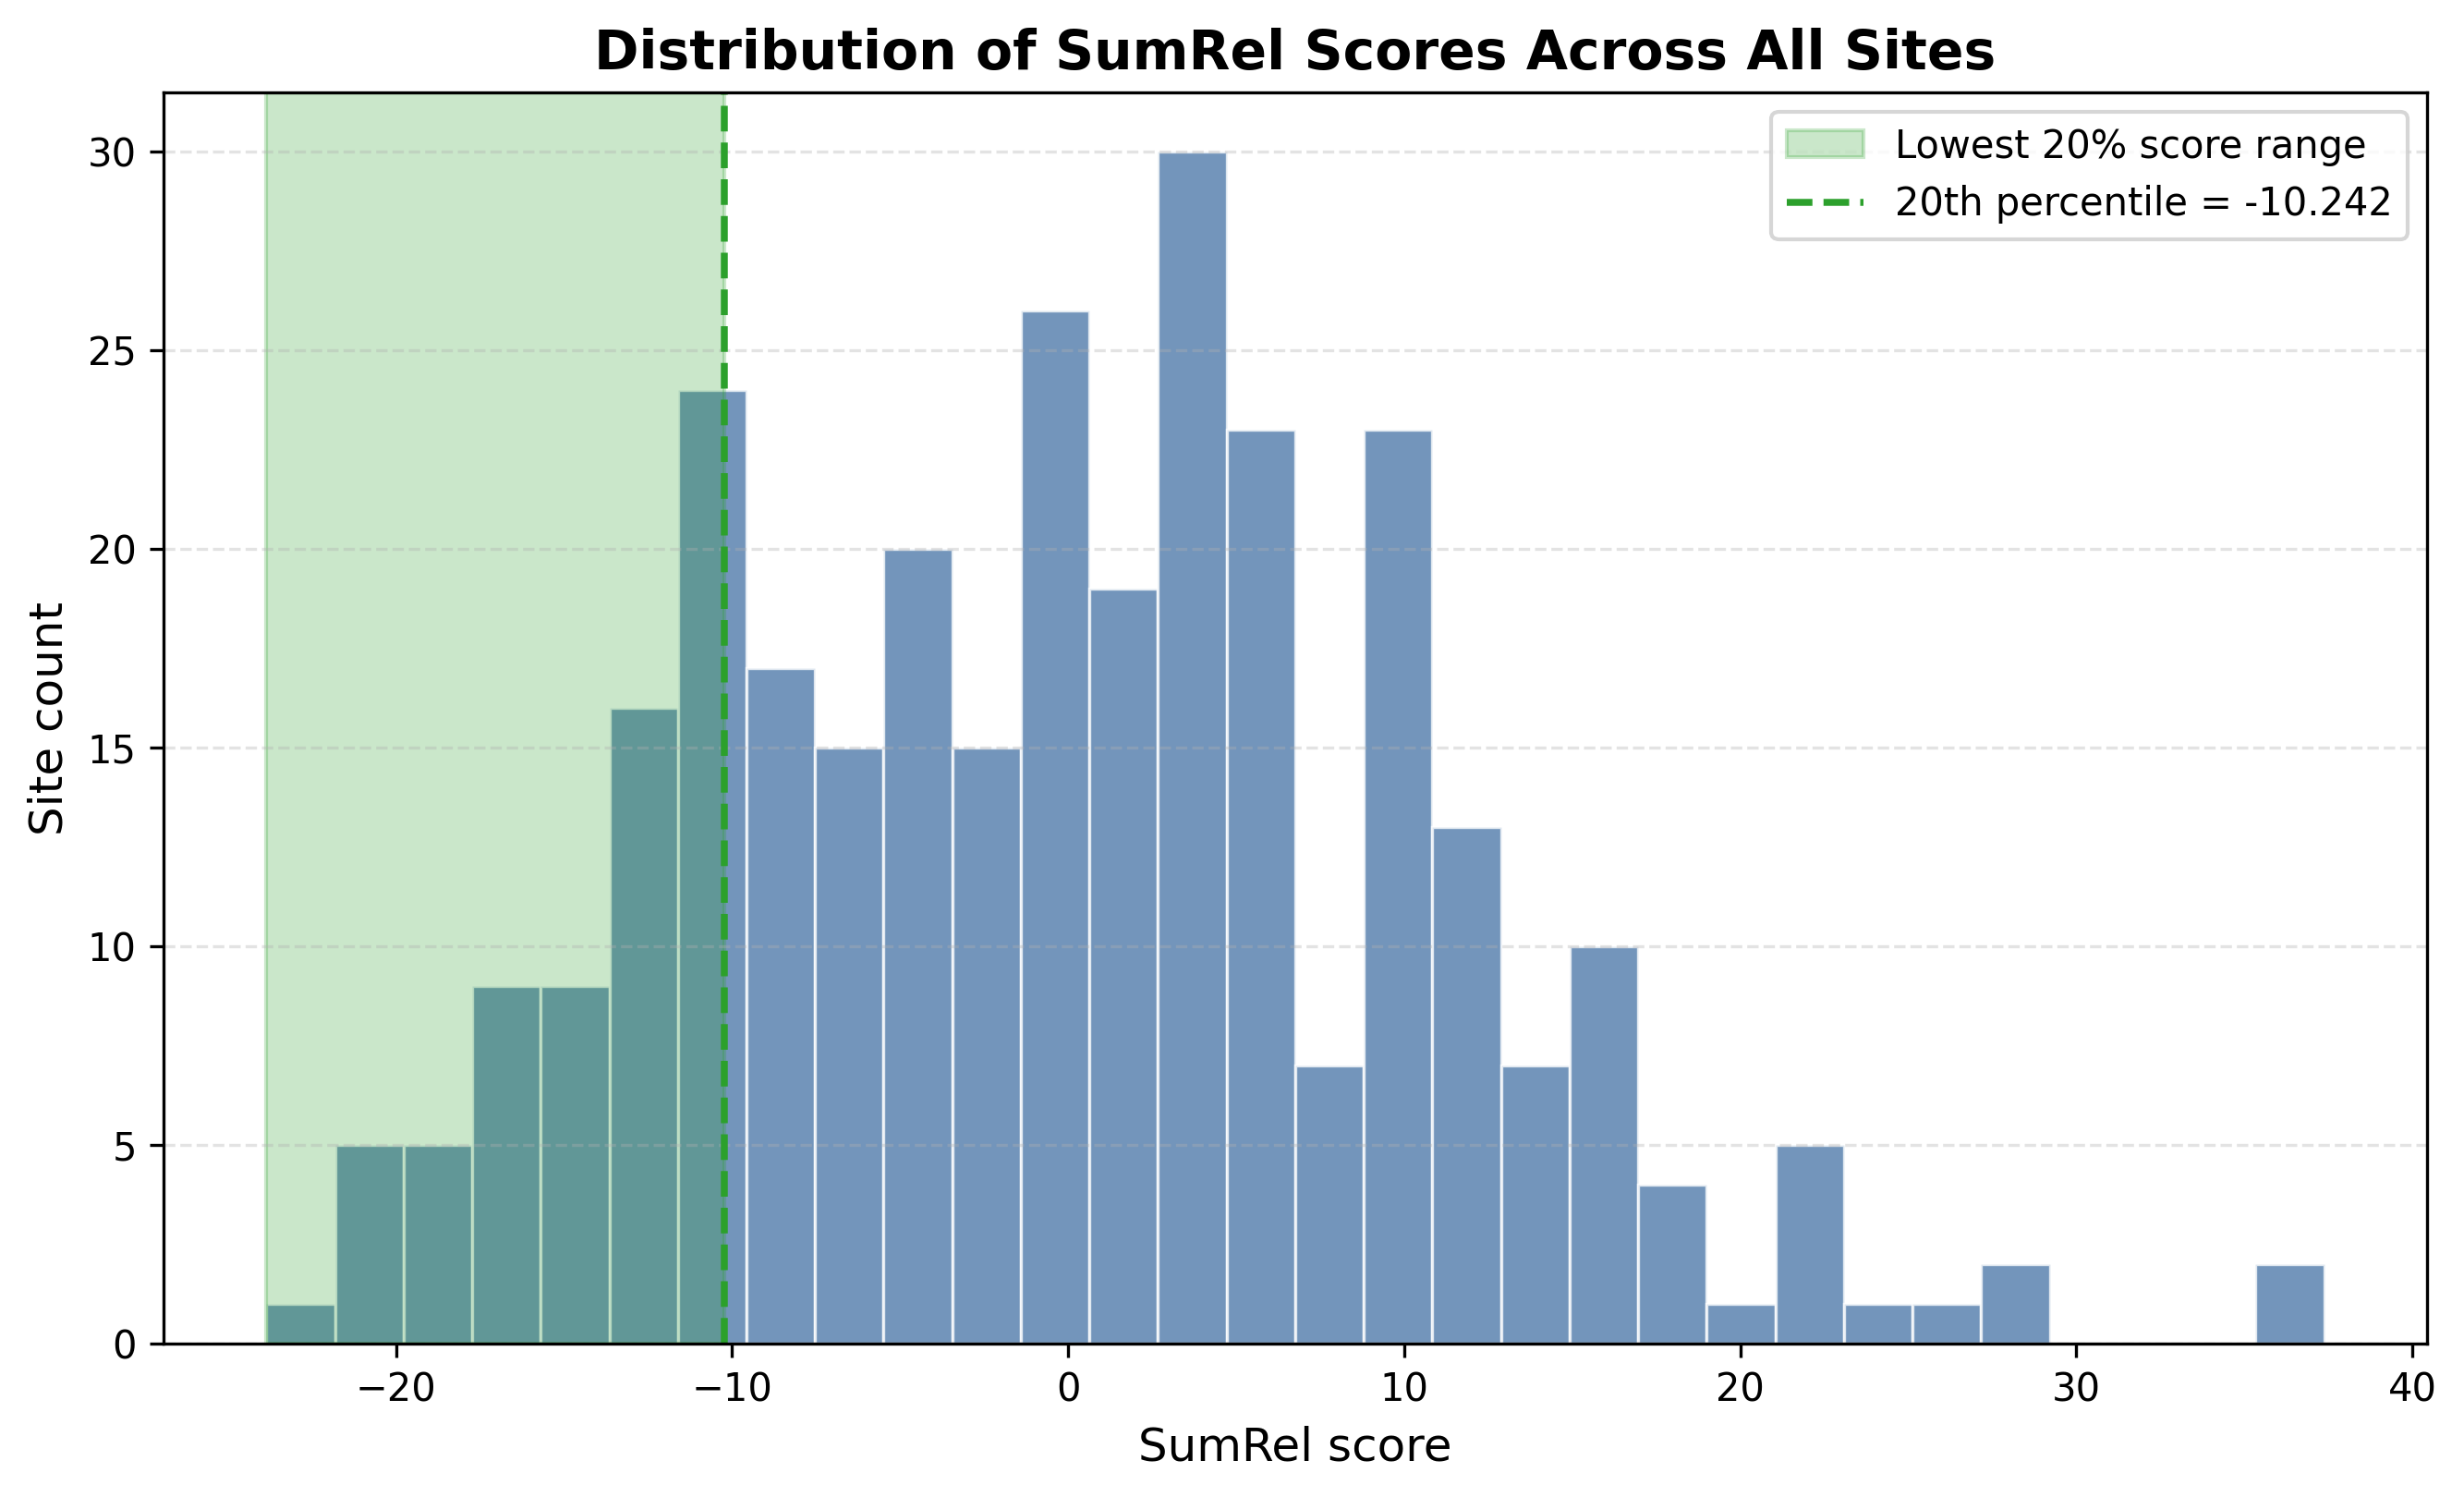

In [35]:
sumrel_all_sites = pd.to_numeric(site_scores_table["SumRel"], errors="coerce").dropna()

if sumrel_all_sites.empty:
    raise ValueError("No valid SumRel scores are available for histogram plotting.")

sumrel_low20_cutoff = float(sumrel_all_sites.quantile(0.20))

sumrel_hist_figure, sumrel_hist_axis = plt.subplots(figsize=(9.0, 5.5), dpi=300)
sumrel_hist_axis.hist(
    sumrel_all_sites,
    bins=30,
    color="#4c78a8",
    alpha=0.78,
    edgecolor="white",
    linewidth=0.8,
)
sumrel_hist_axis.axvspan(
    float(sumrel_all_sites.min()),
    sumrel_low20_cutoff,
    color="#2ca02c",
    alpha=0.25,
    label="Lowest 20% score range",
)
sumrel_hist_axis.axvline(
    sumrel_low20_cutoff,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.8,
    label=f"20th percentile = {sumrel_low20_cutoff:.3f}",
)

sumrel_hist_axis.set_title("Distribution of SumRel Scores Across All Sites", fontsize=14, fontweight="bold")
sumrel_hist_axis.set_xlabel("SumRel score", fontsize=12)
sumrel_hist_axis.set_ylabel("Site count", fontsize=12)
sumrel_hist_axis.grid(axis="y", linestyle="--", alpha=0.35)
sumrel_hist_axis.legend(frameon=True)
sumrel_hist_figure.tight_layout()

print(f"All-site SumRel count: {len(sumrel_all_sites)}")
print(f"20th percentile cutoff: {sumrel_low20_cutoff:.5f}")
display(sumrel_hist_figure)
plt.close(sumrel_hist_figure)